# Chapter 21 — Spark SQL, Catalogs, Views, and Managed Tables

In this chapter, we explore **Spark SQL** — the module in Apache Spark that lets you query structured data using standard SQL alongside the PySpark DataFrame API. Under the hood, both SQL queries and DataFrame code compile into the exact same Catalyst execution plans and run on the Tungsten execution engine with identical performance.

We will cover:
1. **The Spark Catalog** — understanding metadata (schemas, column names, partitions, databases) and checking the active catalog implementation (`in-memory` vs `hive`).
2. **Temporary Views vs. Managed Tables** — creating session-scoped views with `createOrReplaceTempView()`, understanding `isTemporary`, and creating persistent tables with `saveAsTable()`.
3. **Querying Data with SQL** — running `spark.sql()`, filtering, using date functions (`date_format()`), and chaining SQL results back into DataFrames.
4. **SQL Join Hints** — steering Catalyst's join optimizer using `/*+ BROADCAST() */` and `/*+ SHUFFLE_MERGE() */`.
5. **Storage Layout in `spark-warehouse/`** — how Spark organizes Parquet files on disk for managed tables.
6. **Persistent Metadata with Hive Metastore** — using `enableHiveSupport()`, understanding `metastore_db`, and solving table overwrite errors with `.mode("overwrite")`.

---


In [1]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder.appName("sparl_SQL").master("local[*]").getOrCreate())
spark

#### ☝️ Creating the SparkSession with Default In-Memory Catalog

This cell starts a local SparkSession with `.master("local[*]")`. By default (without calling `.enableHiveSupport()`), Spark initializes an **in-memory catalog**. This means any databases or tables you register exist strictly in driver RAM and will disappear when the Spark application terminates.

---


In [2]:
# Read Employee data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"
emp = spark.read.format("csv").schema(_schema).option("header", True).load("data/csv/employee_records.csv")

# Read DEPT CSV data
_dept_schema = "department_id int, department_name string, description string, city string, state string, country string"
dept = spark.read.format("csv").schema(_dept_schema).option("header", True).load("data/csv/department_data.csv")

#### ☝️ Loading Raw Employee and Department Data

We load `employee_records.csv` and `department_data.csv` into PySpark DataFrames `emp` and `dept` using explicit DDL schemas. At this point, Spark knows about these DataFrames as Python variables in memory, but they are not yet accessible inside SQL queries because they haven't been registered in Spark's Catalog.

---


## 📝 1. What is the Spark Catalog and Metadata?

**The Spark Catalog is the central metadata repository that keeps track of databases, tables, views, and functions.**

```text
┌──────────────────────────────────────────────────────────────────┐
│                   METADATA vs ACTUAL DATA                        │
├──────────────────────────────────────────────────────────────────┤
│ 1. CATALOG (Metadata in RAM or Hive Metastore):                  │
│    - Database names: default, sales_db                           │
│    - Table & View names: emp_view, dept_view, emp_final          │
│    - Schema: first_name STRING, salary DOUBLE, dept_id INT       │
│    - Format: parquet, csv                                        │
│    - Physical Location: file:/home/jupyter/spark-warehouse/...   │
│                                                                  │
│                           │ points to                            │
│                           ▼                                      │
│ 2. STORAGE (Actual Data on Disk / S3 / HDFS):                    │
│    - part-00000-xxxx.snappy.parquet                              │
│    - part-00001-xxxx.snappy.parquet                              │
│    - Raw rows and columns of data                                │
└──────────────────────────────────────────────────────────────────┘
```

1. **Metadata is "data about data"**: It does not hold the employee records themselves. It records what columns exist, their data types, and where the raw files live on storage.
2. **Catalog Decouples Queries from File Paths**: Instead of writing `spark.read.load("data/csv/employee_records.csv")` every time, registering a table in the catalog lets you write simple SQL: `SELECT * FROM emp_view`.

---


In [3]:
# Spark Catalog (Metadata) - in-memory/hive
spark.conf.get("spark.sql.catalogImplementation")
# by default we can see the catalog implement information using the catalogImplementation.
# in-memory means catalog will be created in RAM once the session is lot the data will also be lost.
# this is not that good coz if you want to read the same table after a restart the catalog will be lost

'in-memory'

#### ☝️ Checking the Active Catalog Implementation

Calling `spark.conf.get("spark.sql.catalogImplementation")` returns `'in-memory'`. This confirms that Spark is currently keeping all metadata in RAM. When this session stops, the catalog contents will be completely lost.

---


In [4]:
# show databases
db = spark.sql("show databases")
db.show()
# default is the only database available on default

+---------+
|namespace|
+---------+
|  default|
+---------+



In [5]:
spark.sql("show tables in default").show()

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
+---------+---------+-----------+



#### ☝️ Inspecting Databases and Tables

Running `spark.sql("show databases")` reveals `default` — the built-in sandbox database. Running `spark.sql("show tables in default")` shows an empty table list because we haven't registered any views or created any tables yet.

---


In [6]:
# to register dataframe as temp view
emp.createOrReplaceTempView("emp_view")
dept.createOrReplaceTempView("dept_view")
# global temp view will make the temp view created available for all the spark sessions.
# normal temp view createOrReplaceTempView will be available only for this session.

In [7]:
spark.sql("show tables in default").show()

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
|         |dept_view|       true|
|         | emp_view|       true|
+---------+---------+-----------+



#### ☝️ Registering DataFrames as Temporary Views

Here we call `.createOrReplaceTempView("emp_view")` and `.createOrReplaceTempView("dept_view")`:
- **What it does:** It registers the DataFrame under a friendly table name in the active session's catalog.
- **No Data Duplication:** This does *not* copy data or write files to disk. It merely creates an alias / pointer in the catalog to the DataFrame.
- **Session Scoped:** A temporary view is local to this specific `SparkSession`. Other notebooks or sessions cannot see it. (To share across sessions, you would use `createGlobalTempView()`, which places the view into the `global_temp` database).

---


## 📝 2. Temporary Views vs. Permanent Tables

**In Spark SQL, a Temporary View is an in-memory pointer, while a Table has persistent metadata and physical data files.**

```text
┌───────────────────────────┬──────────────────────────────────────┐
│  Temporary View           │  Managed Table                       │
├───────────────────────────┼──────────────────────────────────────┤
│ • isTemporary = true      │ • isTemporary = false                │
│ • Lives only in RAM       │ • Stored on disk (spark-warehouse/)  │
│ • Dies when session ends  │ • Survives session restarts          │
│ • Created from DataFrame  │ • Created with .saveAsTable()        │
│   via createTempView()    │                                      │
└───────────────────────────┴──────────────────────────────────────┘
```

When you query `show tables in default`, the column `isTemporary` distinguishes views from tables:
- `isTemporary = true`: It is a view pointing to an active in-memory DataFrame.
- `isTemporary = false`: It is a true table registered with permanent catalog metadata.

---


In [8]:
# to view data from the table
spark.sql("""
select * from emp_view
""")
# so this will just create the dataframe to see it we must use .show()

DataFrame[first_name: string, last_name: string, job_title: string, dob: string, email: string, phone: string, salary: double, department_id: int]

In [9]:
spark.sql("""
select * from emp_view
""").show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|
|  Michelle|   Elliott|      Air cabin crew|1975-03-31|tiffanyjohnston@e...|       (705)900-5337|604738.0|            8|
|    Ashley|   Montoya|        C

In [10]:
spark.sql("""
select * from emp_view where department_id = 1
""").show()

+-----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+
| first_name|last_name|           job_title|       dob|               email|               phone|  salary|department_id|
+-----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+
|       John|   Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|
|    Rachael|Rodriguez|         Media buyer|1966-12-02|griffinmary@examp...| +1-791-344-7586x548|544732.0|            1|
|Christopher| Callahan| Exhibition designer|1966-10-23| qwalter@example.com|001-947-745-3939x...|251057.0|            1|
|    Lindsey|   Huerta|Embryologist, cli...|1964-10-20|  psmith@example.net|   527.934.6665x1378|878257.0|            1|
|      David|   Harris|   Company secretary|1990-04-13|     nli@example.com|001-959-766-1180x...|249553.0|            1|
|      Brian|Hernandez|     Thea

#### ☝️ Querying Views with SQL Expressions and Filters

Key observations from these queries:
1. `spark.sql("select * from emp_view")` returns a PySpark **DataFrame**. Because Spark is lazy, no computation runs until you call an action like `.show()`.
2. `where department_id = 1`: Standard SQL clauses (`WHERE`, `ORDER BY`, `GROUP BY`) work seamlessly and are optimized by Catalyst just like `.filter()`.

---


In [11]:
# Create a new column dob_year and register as temp view
spark.sql("""
    select e.*, date_format(dob, 'yyyy') as dob_year from emp_view e
    where department_id = 1
""").show()

# all the functions available in the spark dataframe api will be also available on the spark sql

+-----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+
| first_name|last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|
+-----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+
|       John|   Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|    1968|
|    Rachael|Rodriguez|         Media buyer|1966-12-02|griffinmary@examp...| +1-791-344-7586x548|544732.0|            1|    1966|
|Christopher| Callahan| Exhibition designer|1966-10-23| qwalter@example.com|001-947-745-3939x...|251057.0|            1|    1966|
|    Lindsey|   Huerta|Embryologist, cli...|1964-10-20|  psmith@example.net|   527.934.6665x1378|878257.0|            1|    1964|
|      David|   Harris|   Company secretary|1990-04-13|     nli@example.com|001-959-766-11

#### ☝️ Spark SQL Built-in Functions

In this query, `date_format(dob, 'yyyy') as dob_year` extracts the 4-digit birth year. Every function available in `pyspark.sql.functions` (like `date_format`, `concat`, `coalesce`, `when`) can be used directly inside SQL string queries with identical syntax.

---


In [13]:
# Create a new column dob_year and register as temp view
emp_temp = spark.sql("""
    select e.*, date_format(dob, 'yyyy') as dob_year from emp_view e
""")
emp_temp.createOrReplaceTempView("emp_temp_view")
spark.sql("show tables in default").show()
spark.sql("select * from emp_temp_view").show()

+---------+-------------+-----------+
|namespace|    tableName|isTemporary|
+---------+-------------+-----------+
|         |    dept_view|       true|
|         |emp_temp_view|       true|
|         |     emp_view|       true|
+---------+-------------+-----------+

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|    1973|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|    1974|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873

#### ☝️ Materializing Transformed Results into a New View

We transform `emp_view` by adding `dob_year`, assign the resulting DataFrame to `emp_temp`, and call `emp_temp.createOrReplaceTempView("emp_temp_view")`. Now `show tables` displays three views: `dept_view`, `emp_view`, and `emp_temp_view`.

---


In [15]:
# doing join 
spark.sql("""
    select e.*,d.department_name from emp_temp_view e left outer join dept_view d on e.department_id =d.department_id
""").show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|     department_name|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|    1973|          Parker PLC|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|    1974|         Ward-Gordon|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|    1990|      Delgado-Keller|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x6

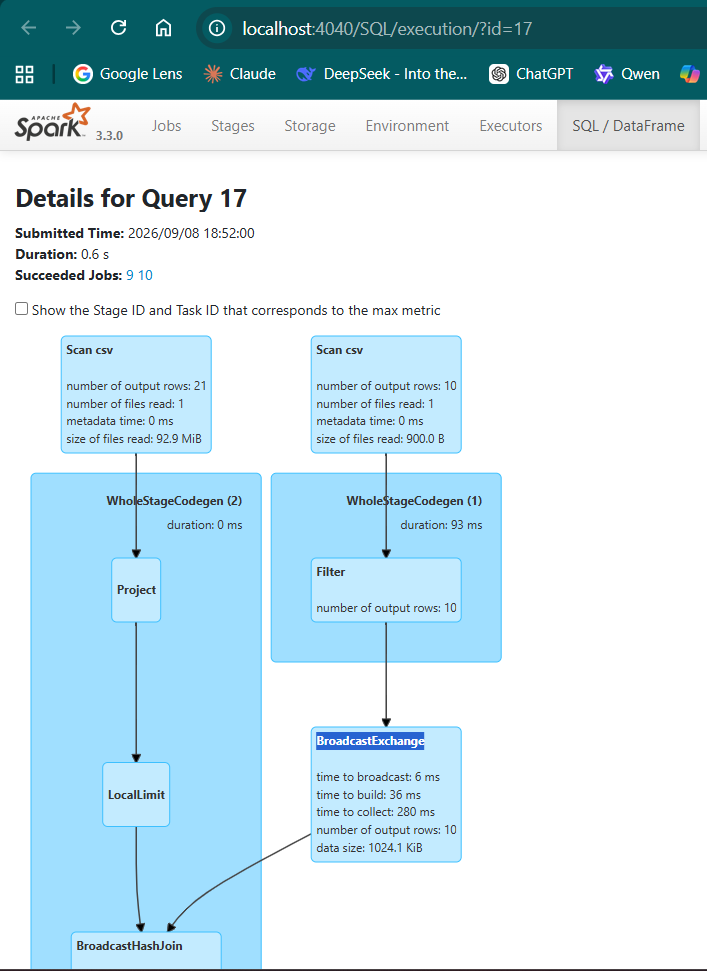

#### ☝️ Automatic Broadcast Hash Join via Catalyst & AQE

When joining `emp_temp_view` with `dept_view` on `department_id`, Spark's execution plan shows a **BroadcastHashJoin** (`BroadcastExchange` + `BroadcastHashJoin`). Because `dept_view` is tiny, Catalyst and Adaptive Query Execution (AQE) automatically broadcast it to all executors to avoid an expensive network shuffle.

---


In [17]:
# consider we dont want broadcast join we want a shuffle join. for that we need to add a HINT infront of the coloum name  */+ /*
spark.sql("""
    select /*+ SHUFFLE_MERGE(e)*/
    e.*,d.department_name from emp_temp_view e left outer join dept_view d on e.department_id = d.department_id
""").show()

+----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+---------------+
|first_name|last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|department_name|
+----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+---------------+
|      John|   Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|    1968|    Bryan-James|
|   Rachael|Rodriguez|         Media buyer|1966-12-02|griffinmary@examp...| +1-791-344-7586x548|544732.0|            1|    1966|    Bryan-James|
|   Gregory|    Adams|Plant breeder/gen...|1977-08-15|bmelendez@example...|   488.890.8299x5153|394487.0|            1|    1977|    Bryan-James|
|     Frank|   Hughes|          Astronomer|1994-01-13|sandra55@example.org|        767.297.4797|107833.0|            1|    1994|  

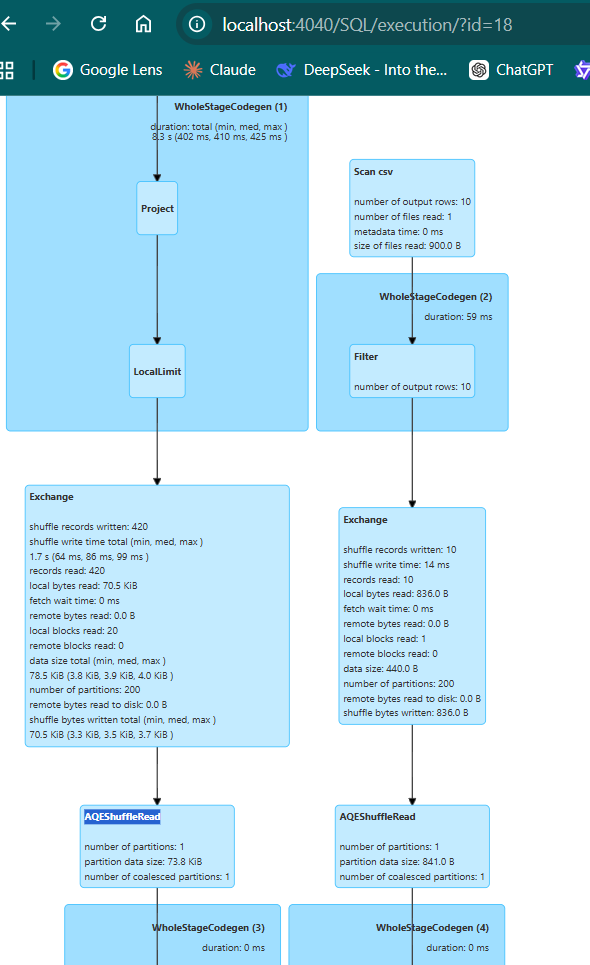

## 📝 3. Overriding the Optimizer: SQL Join Hints

**SQL Join Hints allow developers to explicitly dictate the join algorithm chosen by the Catalyst optimizer.**

```text
┌──────────────────────────────────────────────────────────────────┐
│                      JOIN HINT COMPARISON                        │
├──────────────────────────────────────────────────────────────────┤
│ 1. /*+ SHUFFLE_MERGE(table) */                                  │
│    Forces Sort-Merge Join:                                       │
│    Data from both sides is hashed, shuffled over the network     │
│    (Exchange), sorted by key, and merged.                        │
│                                                                  │
│ 2. /*+ BROADCAST(table) */                                       │
│    Forces Broadcast Hash Join:                                   │
│    The small table is collected to the driver and sent to all    │
│    executors. Zero shuffle on the large table!                   │
└──────────────────────────────────────────────────────────────────┘
```

1. In cell 17, `/*+ SHUFFLE_MERGE(e) */` forced Spark to use **SortMergeJoin**. The plan inserted an `Exchange hashpartitioning` (shuffle) and `Sort` stage on both sides.
2. In cell 19, `/*+ BROADCAST(d) */` instructs Spark to broadcast `dept_view` regardless of table size or auto-broadcast configurations.

---


In [18]:
# if we want to broadcast the dept_view we can use BROADCAST
spark.sql("""
    select /*+ BROADCAST(d)*/
    e.*,d.department_name from emp_temp_view e left outer join dept_view d on e.department_id = d.department_id
""").show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|     department_name|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|    1973|          Parker PLC|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|    1974|         Ward-Gordon|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|    1990|      Delgado-Keller|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x6

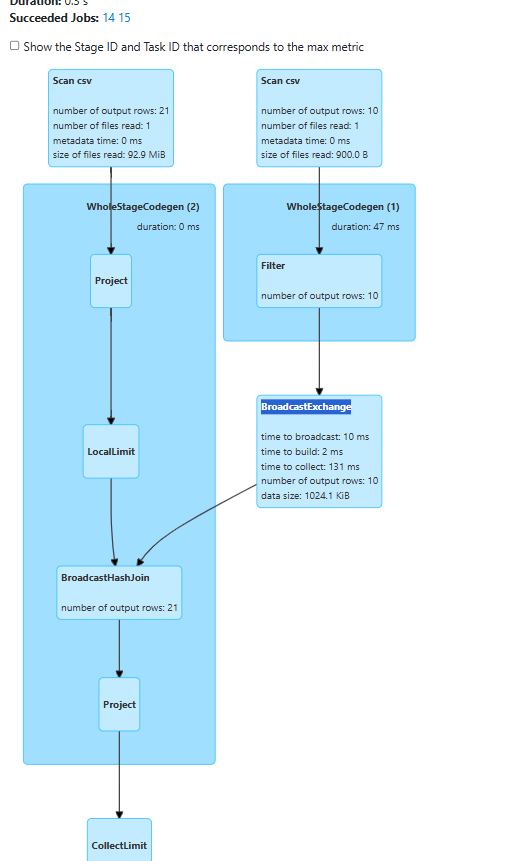

#### ☝️ Broadcast Hint Applied

Spark confirms the `BroadcastExchangeExec` stage, broadcasting `dept_view` to all worker nodes.

---


In [19]:
emp_final = spark.sql("""
    select /*+ BROADCAST(d)*/
    e.*,d.department_name from emp_temp_view e left outer join dept_view d on e.department_id = d.department_id
""")
emp_final.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|     department_name|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|    1973|          Parker PLC|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|    1974|         Ward-Gordon|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|    1990|      Delgado-Keller|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x6

In [ ]:
# now we need to write the data as table 
emp_final.write.format("parquet").saveAsTable("emp_final")
# so the spark by default create a folder called spark-warehouse and save it.
# and also it will be saved direcly into the catalog.and 
# see its isTemporary is false that means its a table now not a view

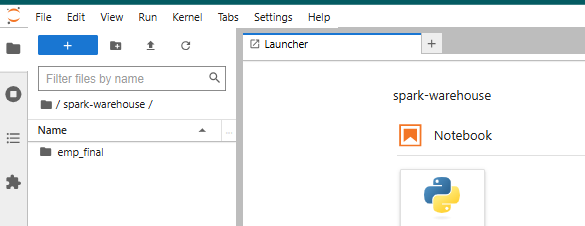

## 📝 4. Creating a Managed Table with `saveAsTable()`

**`df.write.saveAsTable("table_name")` creates a Managed Table, storing metadata in the catalog and writing physical files to the warehouse.**

```text
┌──────────────────────────────────────────────────────────────────┐
│              CREATING A MANAGED TABLE (saveAsTable)              │
├──────────────────────────────────────────────────────────────────┤
│ 1. In-Memory Catalog:                                            │
│    Registers table schema: default.emp_final (isTemporary=false) │
│                                                                  │
│ 2. Local File System:                                            │
│    Creates directory: /home/jupyter/spark-warehouse/emp_final/   │
│    Writes Parquet data files: part-00000-xxxx.parquet            │
└──────────────────────────────────────────────────────────────────┘
```

1. **Default Storage Directory**: Spark automatically places managed tables in `spark.sql.warehouse.dir` (here `spark-warehouse/emp_final/`).
2. **Format**: By default, Spark writes the underlying files in high-performance columnar **Parquet** format.
3. **Table vs View in Catalog**: In `show tables in default`, `emp_final` now appears with `isTemporary = false`. It is an official table, not just a view!

---


In [21]:
spark.sql("show tables in default").show()

+---------+-------------+-----------+
|namespace|    tableName|isTemporary|
+---------+-------------+-----------+
|  default|    emp_final|      false|
|         |    dept_view|       true|
|         |emp_temp_view|       true|
|         |     emp_view|       true|
+---------+-------------+-----------+



In [22]:
# if we want to read it as a table 
emp_new = spark.read.table("emp_final")
emp_new.show()

+-----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
| first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|     department_name|
+-----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|  Christina|   Morales|Glass blower/desi...|1999-10-17|kcardenas@example...|   (420)589-2186x104|838329.0|            3|    1999|Pittman, Hess and...|
|     Robert|  Hatfield| Production engineer|1982-01-24|jenniferunderwood...|  (237)456-1495x9683|156231.0|            3|    1982|Pittman, Hess and...|
|       Mark|     White|Health service ma...|1979-04-10|fitzpatrickjoseph...|          5335210876|739144.0|            6|    1979|         Sanders LLC|
|   Veronica|    Herman|Psychologist, edu...|1989-09-06|vanessamendez@exa...|       (289

In [23]:
# since the emp_final already registered in the catalog can we read it in the SQL querry directly ?
emp_new = spark.sql("select * from emp_final")
emp_new.show()

+-----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
| first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|     department_name|
+-----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|  Christina|   Morales|Glass blower/desi...|1999-10-17|kcardenas@example...|   (420)589-2186x104|838329.0|            3|    1999|Pittman, Hess and...|
|     Robert|  Hatfield| Production engineer|1982-01-24|jenniferunderwood...|  (237)456-1495x9683|156231.0|            3|    1982|Pittman, Hess and...|
|       Mark|     White|Health service ma...|1979-04-10|fitzpatrickjoseph...|          5335210876|739144.0|            6|    1979|         Sanders LLC|
|   Veronica|    Herman|Psychologist, edu...|1989-09-06|vanessamendez@exa...|       (289

#### ☝️ Reading Managed Tables: API vs SQL

Once a table is registered in the catalog, you can read it in two equivalent ways:
1. **DataFrameReader API**: `spark.read.table("emp_final")`
2. **Spark SQL**: `spark.sql("select * from emp_final")`

Both produce identical DataFrames and benefit from full Catalyst optimizations.

---


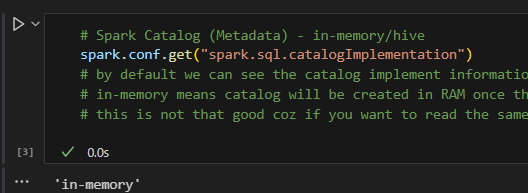
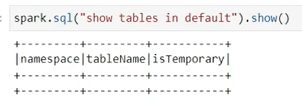

## 📝 5. The In-Memory Trap: Why Metadata Vanishes on `spark.stop()`

**When using the default in-memory catalog, stopping the SparkSession destroys all table definitions while leaving data files orphaned on disk.**

```text
┌──────────────────────────────────────────────────────────────────┐
│              IN-MEMORY CATALOG LIFECYCLE HAZARD                  │
├──────────────────────────────────────────────────────────────────┤
│ Before spark.stop():                                             │
│   Catalog (RAM):      emp_final table definition exists          │
│   Disk (Storage):     spark-warehouse/emp_final/ files exist     │
│                                                                  │
│ spark.stop() is called:                                          │
│   Catalog (RAM):      WIPED OUT (Session memory cleared!)        │
│   Disk (Storage):     spark-warehouse/emp_final/ STILL ON DISK!  │
│                                                                  │
│ New Session starts:                                              │
│   Catalog (RAM):      EMPTY (emp_final is GONE!)                 │
│   Disk (Storage):     ORPHANED FOLDER remains on disk            │
└──────────────────────────────────────────────────────────────────┘
```

Because the catalog was `'in-memory'`, Spark has amnesia upon restarting. The files exist on disk, but Spark no longer has the metadata linking `emp_final` to those files.

---


In [24]:
spark.stop()

In [25]:
# by using HIVE catalog implementation we can persist this metadata

from pyspark.sql import SparkSession

spark = (SparkSession.builder
.appName("sparl_SQL")
.master("local[*]")
.enableHiveSupport()
.getOrCreate()
)
spark

#### ☝️ Enabling Persistent Metadata with Hive Support

To make metadata survive restarts, we create a new `SparkSession` with `.enableHiveSupport()`. This instructs Spark to persist all database, table, and partition schemas into a persistent Hive Metastore database (by default an embedded Apache Derby instance in `metastore_db/`).

---


In [26]:
# Read Employee data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"
emp = spark.read.format("csv").schema(_schema).option("header", True).load("data/csv/employee_records.csv")

# Read DEPT CSV data
_dept_schema = "department_id int, department_name string, description string, city string, state string, country string"
dept = spark.read.format("csv").schema(_dept_schema).option("header", True).load("data/csv/department_data.csv")

In [29]:
spark.conf.get("spark.sql.catalogImplementation")

'hive'

In [30]:
db = spark.sql("show databases")
db.show()
spark.sql("show tables in default").show()

+---------+
|namespace|
+---------+
|  default|
+---------+

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
+---------+---------+-----------+



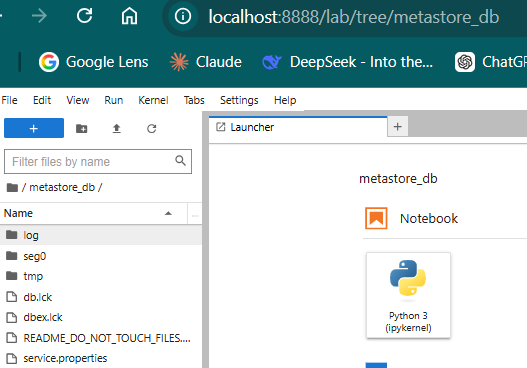

#### ☝️ Confirming the Hive Catalog & `metastore_db`

Notice:
1. `spark.conf.get("spark.sql.catalogImplementation")` now returns `'hive'`.
2. In the working directory, a new folder named `metastore_db` has been created. This embedded database stores all table definitions persistently on disk.
3. Running `show tables in default` shows no tables yet because this Hive metastore is fresh and has not yet registered `emp_final`.

---


In [31]:
# to register dataframe as temp view
emp.createOrReplaceTempView("emp_view")
dept.createOrReplaceTempView("dept_view")

In [32]:
spark.sql("show tables in default").show()

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
|         |dept_view|       true|
|         | emp_view|       true|
+---------+---------+-----------+



In [33]:
emp_final = spark.sql("""
    select /*+ BROADCAST(d)*/
    e.*,d.department_name from emp_view e left outer join dept_view d on e.department_id = d.department_id
""")
emp_final.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|     department_name|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|          Parker PLC|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|         Ward-Gordon|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|      Delgado-Keller|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|         Bryan-James|
|  Mic

#### ☝️ Re-registering Session Views and Preparing `emp_final`

Since temporary views are session-scoped, we re-register `emp_view` and `dept_view` in our new Hive session, then recreate `emp_final` using the broadcast join.

---


In [41]:
emp_final.write \
    .format("parquet") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("emp_final")

## 📝 6. Resolving the Warehouse Collision: Why `.mode("overwrite")` is Required

**When creating a managed table over an existing storage folder, Spark raises `AnalysisException` unless granted explicit overwrite permission.**

```text
┌──────────────────────────────────────────────────────────────────┐
│              THE "LOCATION ALREADY EXISTS" COLLISION             │
├──────────────────────────────────────────────────────────────────┤
│ 1. DROP TABLE IF EXISTS emp_final:                               │
│    Checks Hive Metastore -> Table not found -> Does nothing!     │
│    (The orphaned folder from Session 1 is untouched!)            │
│                                                                  │
│ 2. saveAsTable("emp_final") with default mode("error"):          │
│    Checks disk path: spark-warehouse/emp_final/                  │
│    Folder exists! -> FAILS with AnalysisException                │
│                                                                  │
│ 3. FIX: .mode("overwrite").option("overwriteSchema", "true")     │
│    Authorizes Spark to overwrite existing files and replace      │
│    the schema safely.                                            │
└──────────────────────────────────────────────────────────────────┘
```

1. **Why `DROP TABLE` failed to clean up**: `DROP TABLE IF EXISTS` queries the *active* catalog. In the new Hive session, `emp_final` had never been registered, so Hive considered the drop a no-op and never touched the file system.
2. **The Fix**: Adding `.mode("overwrite")` explicitly instructs Spark to wipe and replace the contents of `spark-warehouse/emp_final/`. Adding `.option("overwriteSchema", "true")` ensures that if the schema changed, the metastore schema is refreshed as well.

---


In [42]:
spark.sql("show tables in default").show()

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
|  default|emp_final|      false|
|         |dept_view|       true|
|         | emp_view|       true|
+---------+---------+-----------+



In [43]:
emp_new = spark.sql("select * from emp_final")
emp_new.show()

+-----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------------+
| first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|     department_name|
+-----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------------+
|  Christina|   Morales|Glass blower/desi...|1999-10-17|kcardenas@example...|   (420)589-2186x104|838329.0|            3|Pittman, Hess and...|
|     Robert|  Hatfield| Production engineer|1982-01-24|jenniferunderwood...|  (237)456-1495x9683|156231.0|            3|Pittman, Hess and...|
|       Mark|     White|Health service ma...|1979-04-10|fitzpatrickjoseph...|          5335210876|739144.0|            6|         Sanders LLC|
|   Veronica|    Herman|Psychologist, edu...|1989-09-06|vanessamendez@exa...|       (289)876-1659| 77413.0|            5|          Hardin Inc|

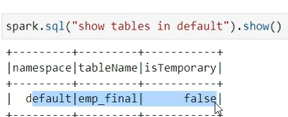

#### ☝️ Persistent Table Verification

We verify the permanent table:
1. `spark.sql("show tables in default")` shows `emp_final` with `isTemporary = false`.
2. `spark.sql("select * from emp_final").show()` successfully queries the table.
3. Even if this SparkSession is stopped and restarted again, the table metadata in `metastore_db` and data files in `spark-warehouse/` will remain fully intact and accessible!

---


In [46]:
spark.sql("describe  emp_final").show()

+---------------+---------+-------+
|       col_name|data_type|comment|
+---------------+---------+-------+
|     first_name|   string|   null|
|      last_name|   string|   null|
|      job_title|   string|   null|
|            dob|   string|   null|
|          email|   string|   null|
|          phone|   string|   null|
|         salary|   double|   null|
|  department_id|      int|   null|
|department_name|   string|   null|
+---------------+---------+-------+



In [47]:
# Show details of metadata
spark.sql("describe extended emp_final").show()

+--------------------+--------------------+-------+
|            col_name|           data_type|comment|
+--------------------+--------------------+-------+
|          first_name|              string|   null|
|           last_name|              string|   null|
|           job_title|              string|   null|
|                 dob|              string|   null|
|               email|              string|   null|
|               phone|              string|   null|
|              salary|              double|   null|
|       department_id|                 int|   null|
|     department_name|              string|   null|
|                    |                    |       |
|# Detailed Table ...|                    |       |
|            Database|             default|       |
|               Table|           emp_final|       |
|               Owner|                root|       |
|        Created Time|Tue Sep 08 19:42:...|       |
|         Last Access|             UNKNOWN|       |
|          C